# 03 – Model Development and Evaluation

## Purpose

This notebook develops, tunes, and evaluates machine learning models to predict whether an exoplanet is a gas giant using only measurable stellar properties.

The training and testing datasets were created in Notebook 02. Model-specific preprocessing is performed inside scikit-learn pipelines in this notebook.

This design ensures that preprocessing operations such as missing-value imputation and feature scaling are learned only from the relevant training data. During cross-validation, each fold independently learns its preprocessing parameters from its own training subset, preventing information from leaking into model development.

To ensure a fair comparison, every model follows the same general workflow:

1. Construct a model-specific preprocessing pipeline.
2. Tune hyperparameters using stratified cross-validation on the training data.
3. Refit the best pipeline using the complete training dataset.
4. Evaluate the final tuned pipeline on the untouched testing dataset.
5. Compare models using consistent performance metrics.

In [76]:
from pathlib import Path

import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.dummy import DummyClassifier

from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    ConfusionMatrixDisplay,
    classification_report
)

In [77]:
Path("../models").mkdir(parents=True, exist_ok=True)

In [78]:
X_train = pd.read_csv(
    "../data/processed/X_train.csv"
)

X_test = pd.read_csv(
    "../data/processed/X_test.csv"
)

y_train = pd.read_csv(
    "../data/processed/y_train.csv"
).squeeze("columns")

y_test = pd.read_csv(
    "../data/processed/y_test.csv"
).squeeze("columns")

print(f"Training observations: {len(X_train):,}")
print(f"Testing observations: {len(X_test):,}")

Training observations: 22,032
Testing observations: 5,508


In [79]:
EXPECTED_FEATURES = [
    "st_teff",
    "st_rad",
    "st_met"
]

assert list(X_train.columns) == EXPECTED_FEATURES
assert list(X_test.columns) == EXPECTED_FEATURES

assert len(X_train) == len(y_train)
assert len(X_test) == len(y_test)

assert set(y_train.unique()) <= {0, 1}
assert set(y_test.unique()) <= {0, 1}

assert pd.api.types.is_integer_dtype(y_train)
assert pd.api.types.is_integer_dtype(y_test)

print("Dataset structure validated successfully.")

Dataset structure validated successfully.


## Confirmed Modeling Feature Schema

Notebook 02 established the final predictor set for this study:

- `st_teff`: host-star effective temperature
- `st_rad`: host-star radius
- `st_met`: host-star metallicity

Notebook 03 does not perform additional feature selection. The purpose of this notebook is to compare models using the fixed feature set defined before model development.

In [80]:
print("Missing values in training data:")
display(X_train.isna().sum())

print("\nMissing values in testing data:")
display(X_test.isna().sum())

Missing values in training data:


st_teff     928
st_rad      352
st_met     6981
dtype: int64


Missing values in testing data:


st_teff     241
st_rad       92
st_met     1765
dtype: int64

In [81]:
class_distribution = pd.DataFrame({
    "Class": [
        "Non-Gas Giant",
        "Gas Giant"
    ],
    "Training Count": [
        (y_train == 0).sum(),
        (y_train == 1).sum()
    ],
    "Testing Count": [
        (y_test == 0).sum(),
        (y_test == 1).sum()
    ]
})

class_distribution

,Class,Training Count,Testing Count
0,Non-Gas Giant,18746,4686
1,Gas Giant,3286,822


In [82]:
print(
    "Training class proportions:"
)

print(
    y_train.value_counts(
        normalize=True
    )
)

Training class proportions:
is_gas_giant
0    0.850853
1    0.149147
Name: proportion, dtype: float64


## Experimental Design

The predictor variables and binary target were defined in Notebook 02 before model development.

The final predictor set consists of:

- `st_teff`: host-star effective temperature
- `st_rad`: host-star radius
- `st_met`: host-star metallicity

The target is `is_gas_giant`, defined using the radius-based threshold established in Notebook 02.

The held-out testing set remains untouched during model development.

The following model families are evaluated:

1. Majority-class baseline
2. Logistic Regression
3. Decision Tree
4. Random Forest
5. Gradient Boosting

For the machine-learning models, hyperparameters are optimized using five-fold stratified cross-validation performed exclusively on the training data.

The testing set is not used for:

- hyperparameter selection
- model selection
- threshold optimization
- preprocessing

In [83]:
dummy_pipeline = DummyClassifier(
    strategy="most_frequent"
)

dummy_pipeline.fit(
    X_train,
    y_train
)

y_pred_dummy = dummy_pipeline.predict(
    X_test
)

dummy_accuracy = accuracy_score(
    y_test,
    y_pred_dummy
)

dummy_precision = precision_score(
    y_test,
    y_pred_dummy,
    zero_division=0
)

dummy_recall = recall_score(
    y_test,
    y_pred_dummy,
    zero_division=0
)

dummy_f1 = f1_score(
    y_test,
    y_pred_dummy,
    zero_division=0
)

print(
    classification_report(
        y_test,
        y_pred_dummy,
        target_names=[
            "Non-Gas Giant",
            "Gas Giant"
        ],
        zero_division=0
    )
)

               precision    recall  f1-score   support

Non-Gas Giant       0.85      1.00      0.92      4686
    Gas Giant       0.00      0.00      0.00       822

     accuracy                           0.85      5508
    macro avg       0.43      0.50      0.46      5508
 weighted avg       0.72      0.85      0.78      5508



In [84]:
results = pd.DataFrame([
    {
        "Model": "Majority-Class Baseline",
        "Mean CV F1": float("nan"),
        "Test Accuracy": round(dummy_accuracy, 3),
        "Test Precision": round(dummy_precision, 3),
        "Test Recall": round(dummy_recall, 3),
        "Test F1": round(dummy_f1, 3),
        "Test ROC-AUC": float("nan"),
        "Test Average Precision": float("nan")
    }
])

results

,Model,Mean CV F1,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Test Average Precision
0,Majority-Class Baseline,NaN,0.851,0.0,0.0,0.0,NaN,NaN


## Model Selection Metric

F1 score is used as the primary model-selection metric because the positive class is less common and the study seeks a balance between identifying true gas giants and limiting false positive classifications.

Accuracy is reported as a secondary metric because it can be inflated by majority-class predictions in imbalanced datasets.

ROC-AUC and Average Precision are calculated using predicted probabilities on the untouched testing set.

In [85]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [ ]:
def evaluate_model(
    model_name,
    pipeline,
    param_grid,
    X_train,
    y_train,
    X_test,
    y_test,
    results_df
):

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=cv,
        scoring="f1",
        n_jobs=-1,
        return_train_score=False
    )

    grid_search.fit(
        X_train,
        y_train
    )

    best_model = grid_search.best_estimator_

    y_pred = best_model.predict(
        X_test
    )

    y_probability = best_model.predict_proba(
        X_test
    )[:, 1]

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_probability
    )

    average_precision = average_precision_score(
        y_test,
        y_probability
    )

    results_df.loc[len(results_df)] = {
        "Model": model_name,
        "Mean CV F1": round(
            grid_search.best_score_,
            3
        ),
        "Test Accuracy": round(
            accuracy,
            3
        ),
        "Test Precision": round(
            precision,
            3
        ),
        "Test Recall": round(
            recall,
            3
        ),
        "Test F1": round(
            f1,
            3
        ),
        "Test ROC-AUC": round(
            roc_auc,
            3
        ),
        "Test Average Precision": round(
            average_precision,
            3
        )
    }

    print(model_name)

    print("\nBest Parameters:")
    print(grid_search.best_params_)

    print("\nBest Cross-Validation F1 Score:")
    print(round(grid_search.best_score_, 3))

    print("\nTest ROC-AUC:")
    print(round(roc_auc, 3))

    print("\nTest Average Precision:")
    print(round(average_precision, 3))

    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "Non-Gas Giant",
                "Gas Giant"
            ],
            zero_division=0
        )
    )

    return (
        best_model,
        y_pred,
        y_probability,
        grid_search
    )

## Baseline Model: Logistic Regression

Logistic Regression serves as the interpretable linear baseline.

The model is placed inside a pipeline containing:

1. Median imputation
2. Standardization
3. Logistic Regression

The preprocessing steps are learned independently inside each cross-validation fold.

In [87]:
logistic_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            random_state=42,
            max_iter=1000
        )
    )
])

logistic_params = {
    "model__C": [
        0.01,
        0.1,
        1,
        10,
        100
    ],
    "model__solver": [
        "liblinear"
    ]
}

In [88]:
(
    best_logistic,
    y_pred_logistic,
    y_probability_logistic,
    logistic_search
) = evaluate_model(
    model_name="Logistic Regression",
    pipeline=logistic_pipeline,
    param_grid=logistic_params,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    results_df=results
)

joblib.dump(
    best_logistic,
    "../models/logistic_regression.joblib"
)

Logistic Regression

Best Parameters:
{'model__C': 1, 'model__solver': 'liblinear'}

Best Cross-Validation F1 Score:
0.098

Test ROC-AUC:
0.723

Test Average Precision:
0.354

Classification Report:
               precision    recall  f1-score   support

Non-Gas Giant       0.86      0.99      0.92      4686
    Gas Giant       0.64      0.06      0.11       822

     accuracy                           0.85      5508
    macro avg       0.75      0.53      0.52      5508
 weighted avg       0.83      0.85      0.80      5508



['../models/logistic_regression.joblib']

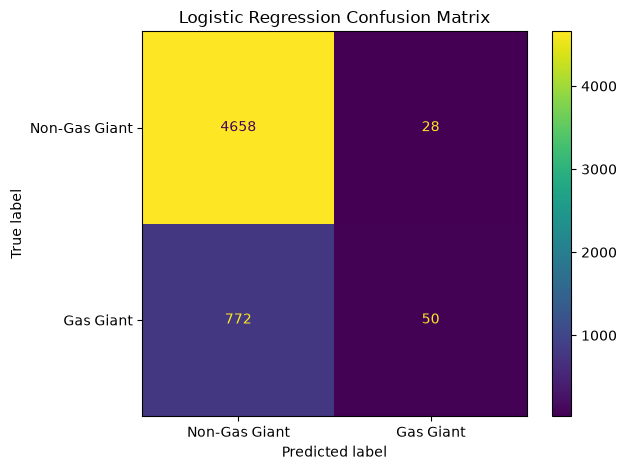

In [89]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic,
    display_labels=[
        "Non-Gas Giant",
        "Gas Giant"
    ]
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [90]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": (
        best_logistic
        .named_steps["model"]
        .coef_[0]
    )
})

coefficients["Absolute Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = (
    coefficients
    .sort_values(
        "Absolute Coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

coefficients["Coefficient"] = (
    coefficients["Coefficient"]
    .round(3)
)

coefficients["Absolute Coefficient"] = (
    coefficients["Absolute Coefficient"]
    .round(3)
)

coefficients

,Feature,Coefficient,Absolute Coefficient
0,st_rad,0.649,0.649
1,st_met,0.451,0.451
2,st_teff,0.161,0.161


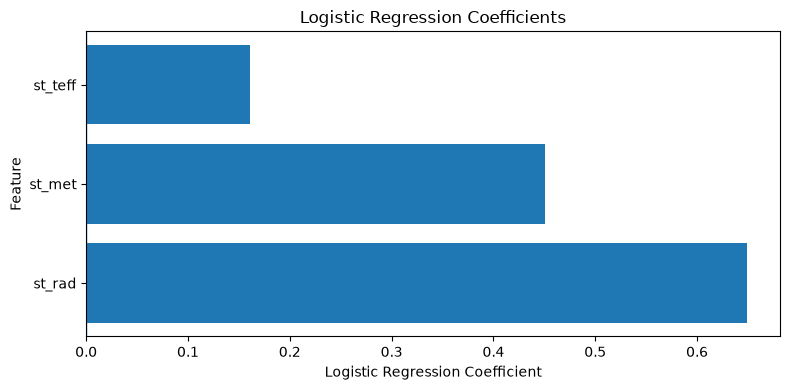

In [91]:
plt.figure(figsize=(8, 4))

plt.barh(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.xlabel(
    "Logistic Regression Coefficient"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Logistic Regression Coefficients"
)

plt.axvline(
    0,
    linewidth=1
)

plt.tight_layout()
plt.show()

## Model 2: Decision Tree Classifier

Decision Trees can capture nonlinear relationships between stellar properties and gas giant classification.

Because unconstrained trees can overfit, tree depth and minimum sample requirements are tuned using cross-validation.

In [92]:
tree_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "model",
        DecisionTreeClassifier(
            random_state=42
        )
    )
])

tree_params = {
    "model__max_depth": [
        2,
        4,
        6,
        8,
        10,
        None
    ],
    "model__min_samples_split": [
        2,
        5,
        10
    ],
    "model__min_samples_leaf": [
        1,
        2,
        5
    ]
}

In [93]:
(
    best_tree,
    y_pred_tree,
    y_probability_tree,
    tree_search
) = evaluate_model(
    model_name="Decision Tree",
    pipeline=tree_pipeline,
    param_grid=tree_params,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    results_df=results
)

joblib.dump(
    best_tree,
    "../models/decision_tree.joblib"
)

Decision Tree

Best Parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}

Best Cross-Validation F1 Score:
0.486

Test ROC-AUC:
0.741

Test Average Precision:
0.404

Classification Report:
               precision    recall  f1-score   support

Non-Gas Giant       0.91      0.94      0.93      4686
    Gas Giant       0.60      0.48      0.53       822

     accuracy                           0.87      5508
    macro avg       0.75      0.71      0.73      5508
 weighted avg       0.86      0.87      0.87      5508



['../models/decision_tree.joblib']

In [94]:
importances = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": (
        best_tree
        .named_steps["model"]
        .feature_importances_
    )
})

importances = (
    importances
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

importances["Importance"] = (
    importances["Importance"]
    .round(3)
)

importances

,Feature,Importance
0,st_rad,0.425
1,st_teff,0.394
2,st_met,0.180


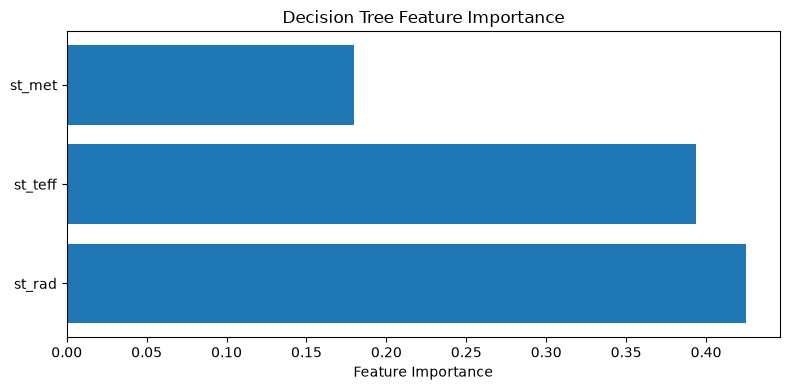

In [95]:
plt.figure(figsize=(8, 4))

plt.barh(
    importances["Feature"],
    importances["Importance"]
)

plt.xlabel(
    "Feature Importance"
)

plt.title(
    "Decision Tree Feature Importance"
)

plt.tight_layout()
plt.show()

## Model 3: Random Forest Classifier

Random Forest combines many decision trees to reduce variance and improve predictive stability.

The model is tuned using:

- number of trees
- maximum depth
- minimum split size
- minimum leaf size
- class weighting

In [96]:
rf_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "model",
        RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        )
    )
])

rf_params = {
    "model__n_estimators": [
        100,
        200
    ],
    "model__max_depth": [
        None,
        10
    ],
    "model__min_samples_split": [
        2,
        5
    ],
    "model__min_samples_leaf": [
        1,
        2
    ],
    "model__class_weight": [
        None,
        "balanced"
    ]
}

In [97]:
(
    best_rf,
    y_pred_rf,
    y_probability_rf,
    rf_search
) = evaluate_model(
    model_name="Random Forest",
    pipeline=rf_pipeline,
    param_grid=rf_params,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    results_df=results
)

joblib.dump(
    best_rf,
    "../models/random_forest.joblib"
)

Random Forest

Best Parameters:
{'model__class_weight': 'balanced', 'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Best Cross-Validation F1 Score:
0.536

Test ROC-AUC:
0.865

Test Average Precision:
0.579

Classification Report:
               precision    recall  f1-score   support

Non-Gas Giant       0.93      0.90      0.91      4686
    Gas Giant       0.51      0.59      0.55       822

     accuracy                           0.85      5508
    macro avg       0.72      0.75      0.73      5508
 weighted avg       0.86      0.85      0.86      5508



['../models/random_forest.joblib']

In [98]:
rf_importances = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": (
        best_rf
        .named_steps["model"]
        .feature_importances_
    )
})

rf_importances = (
    rf_importances
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

rf_importances["Importance"] = (
    rf_importances["Importance"]
    .round(3)
)

rf_importances

,Feature,Importance
0,st_rad,0.408
1,st_teff,0.384
2,st_met,0.208


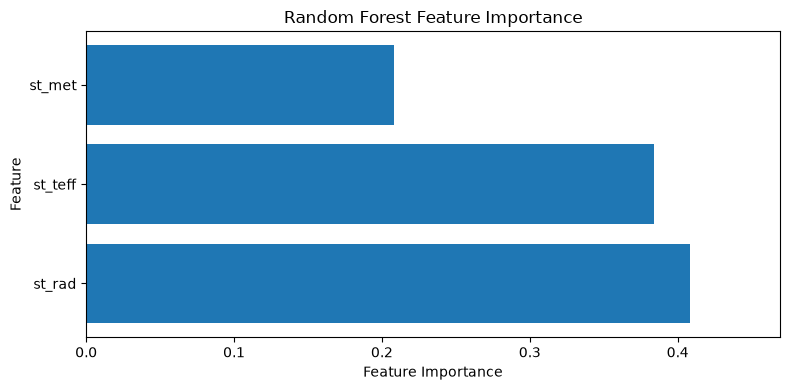

In [99]:
plt.figure(figsize=(8, 4))

plt.barh(
    rf_importances["Feature"],
    rf_importances["Importance"]
)

plt.xlabel(
    "Feature Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.xlim(
    0,
    rf_importances["Importance"].max() * 1.15
)

plt.tight_layout()
plt.show()

## Model 4: Gradient Boosting Classifier

Gradient Boosting builds a sequence of trees in which later trees attempt to correct errors made by earlier trees.

This provides a complementary nonlinear ensemble method to Random Forest.

In [100]:
gradient_boosting_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "model",
        GradientBoostingClassifier(
            random_state=42
        )
    )
])

gradient_boosting_params = {
    "model__n_estimators": [
        50,
        100,
        200
    ],
    "model__learning_rate": [
        0.05,
        0.1
    ],
    "model__max_depth": [
        1,
        2,
        3
    ],
    "model__min_samples_leaf": [
        1,
        2,
        5
    ],
    "model__subsample": [
        0.8,
        1.0
    ]
}

In [101]:
(
    best_gradient_boosting,
    y_pred_gradient_boosting,
    y_probability_gradient_boosting,
    gradient_boosting_search
) = evaluate_model(
    model_name="Gradient Boosting",
    pipeline=gradient_boosting_pipeline,
    param_grid=gradient_boosting_params,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    results_df=results
)

joblib.dump(
    best_gradient_boosting,
    "../models/gradient_boosting.joblib"
)

Gradient Boosting

Best Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_samples_leaf': 5, 'model__n_estimators': 200, 'model__subsample': 0.8}

Best Cross-Validation F1 Score:
0.261

Test ROC-AUC:
0.775

Test Average Precision:
0.446

Classification Report:
               precision    recall  f1-score   support

Non-Gas Giant       0.87      0.99      0.92      4686
    Gas Giant       0.67      0.15      0.25       822

     accuracy                           0.86      5508
    macro avg       0.77      0.57      0.59      5508
 weighted avg       0.84      0.86      0.82      5508



['../models/gradient_boosting.joblib']

In [102]:
gradient_boosting_importances = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": (
        best_gradient_boosting
        .named_steps["model"]
        .feature_importances_
    )
})

gradient_boosting_importances = (
    gradient_boosting_importances
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

gradient_boosting_importances["Importance"] = (
    gradient_boosting_importances["Importance"]
    .round(3)
)

gradient_boosting_importances

,Feature,Importance
0,st_rad,0.474
1,st_teff,0.286
2,st_met,0.241


## Comparative Model Evaluation

The four machine-learning models were evaluated using identical training and testing datasets, the same cross-validation strategy, and consistent evaluation metrics.

The model selected for final analysis is the model with the highest mean cross-validation F1 score.

The test set is used only to evaluate final performance after model selection.

In [103]:
final_metrics = results[
    [
        "Model",
        "Mean CV F1",
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1",
        "Test ROC-AUC",
        "Test Average Precision"
    ]
].copy()

final_metrics

,Model,Mean CV F1,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Test Average Precision
0,Majority-Class Baseline,NaN,0.851,0.000,0.000,0.000,NaN,NaN
1,Logistic Regression,0.098,0.855,0.641,0.061,0.111,0.723,0.354
2,Decision Tree,0.486,0.874,0.598,0.478,0.531,0.741,0.404
3,Random Forest,0.536,0.854,0.509,0.595,0.549,0.865,0.579
4,Gradient Boosting,0.261,0.862,0.668,0.155,0.251,0.775,0.446


In [104]:
model_results = results[
    results["Model"] != "Majority-Class Baseline"
].copy()

model_results = (
    model_results
    .sort_values(
        by="Mean CV F1",
        ascending=False
    )
    .reset_index(drop=True)
)

best_model = model_results.iloc[0]

best_model_name = best_model["Model"]

print(
    f"Selected model: {best_model_name}"
)

print(
    f"Mean CV F1: "
    f"{best_model['Mean CV F1']:.3f}"
)

print(
    f"Test F1: "
    f"{best_model['Test F1']:.3f}"
)

Selected model: Random Forest
Mean CV F1: 0.536
Test F1: 0.549


In [105]:
prediction_lookup = {
    "Logistic Regression": y_pred_logistic,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gradient_boosting
}

probability_lookup = {
    "Logistic Regression": y_probability_logistic,
    "Decision Tree": y_probability_tree,
    "Random Forest": y_probability_rf,
    "Gradient Boosting": y_probability_gradient_boosting
}

best_model_predictions = (
    prediction_lookup[
        best_model_name
    ]
)

best_model_probabilities = (
    probability_lookup[
        best_model_name
    ]
)

In [106]:
best_accuracy = best_model["Test Accuracy"]
best_precision = best_model["Test Precision"]
best_recall = best_model["Test Recall"]
best_f1 = best_model["Test F1"]

print(
    f"Best performing model: "
    f"{best_model_name}"
)

print(
    f"Mean CV F1: "
    f"{best_model['Mean CV F1']:.3f}"
)

print(
    f"Test Accuracy: "
    f"{best_accuracy:.3f}"
)

print(
    f"Test Precision: "
    f"{best_precision:.3f}"
)

print(
    f"Test Recall: "
    f"{best_recall:.3f}"
)

print(
    f"Test F1 Score: "
    f"{best_f1:.3f}"
)

Best performing model: Random Forest
Mean CV F1: 0.536
Test Accuracy: 0.854
Test Precision: 0.509
Test Recall: 0.595
Test F1 Score: 0.549


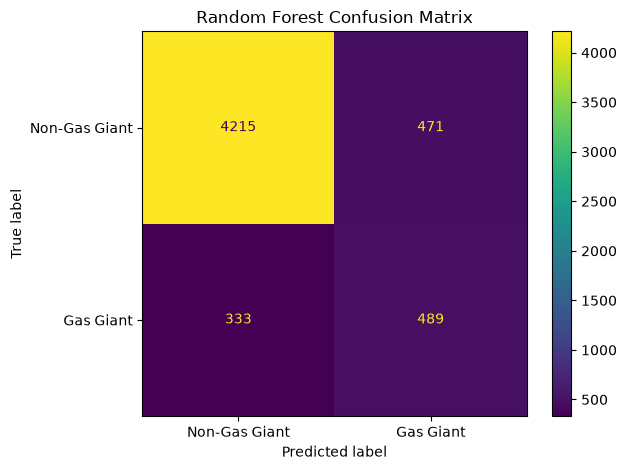

In [107]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_model_predictions,
    display_labels=[
        "Non-Gas Giant",
        "Gas Giant"
    ]
)

plt.title(
    f"{best_model_name} Confusion Matrix"
)

plt.tight_layout()
plt.show()

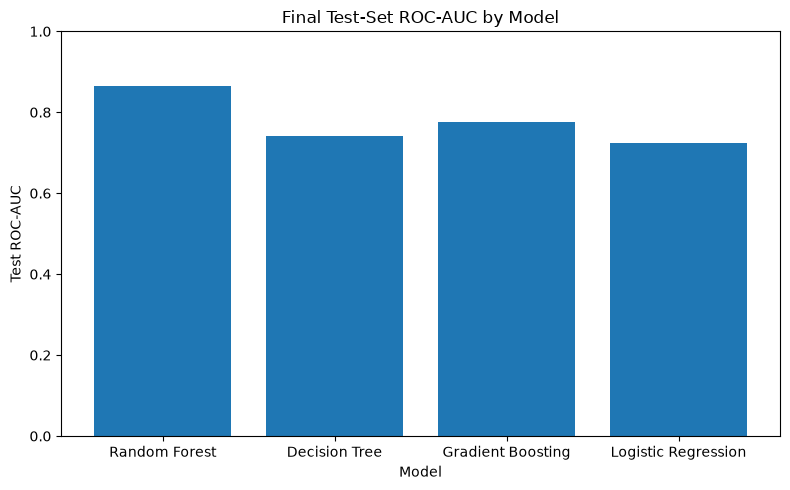

In [108]:
plt.figure(figsize=(8, 5))

plt.bar(
    model_results["Model"],
    model_results["Test ROC-AUC"]
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Test ROC-AUC"
)

plt.title(
    "Final Test-Set ROC-AUC by Model"
)

plt.ylim(
    0,
    1
)

plt.tight_layout()
plt.show()

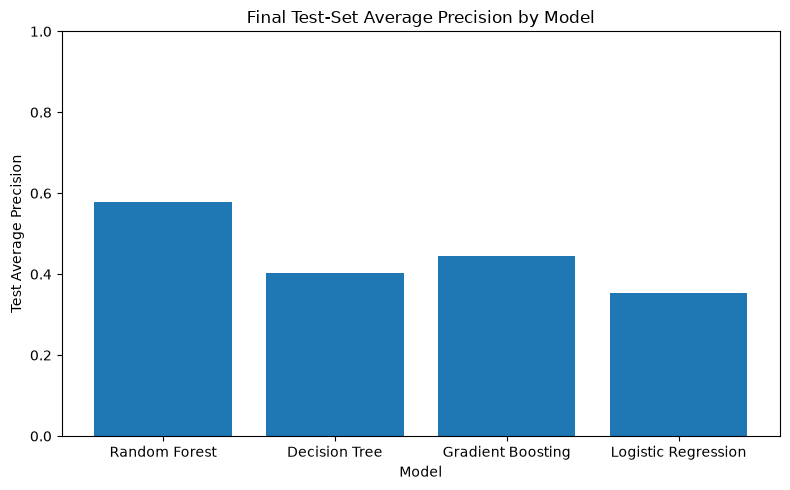

In [109]:
plt.figure(figsize=(8, 5))

plt.bar(
    model_results["Model"],
    model_results["Test Average Precision"]
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Test Average Precision"
)

plt.title(
    "Final Test-Set Average Precision by Model"
)

plt.ylim(
    0,
    1
)

plt.tight_layout()
plt.show()

## Feature Importance Across Models

Different machine-learning algorithms quantify predictor importance using different methodologies.

- Logistic Regression estimates the direction and magnitude of linear relationships through standardized coefficients.
- Decision Trees measure the reduction in impurity produced by feature-based splits.
- Random Forest averages impurity-based feature importance across many independently trained decision trees.
- Gradient Boosting measures impurity-based importance across a sequential ensemble of trees.

The importance values are not directly comparable across algorithms because each model defines importance differently.

Feature importance should therefore be interpreted as evidence of predictive contribution within a specific model, not as evidence that a feature causes a planet to become a gas giant.

In [110]:
comparison = pd.DataFrame({
    "Feature": X_train.columns,

    "Logistic |Standardized Coefficient|":
        coefficients
        .set_index("Feature")
        .loc[
            X_train.columns,
            "Absolute Coefficient"
        ],

    "Decision Tree":
        importances
        .set_index("Feature")
        .loc[
            X_train.columns,
            "Importance"
        ],

    "Random Forest":
        rf_importances
        .set_index("Feature")
        .loc[
            X_train.columns,
            "Importance"
        ],

    "Gradient Boosting":
        gradient_boosting_importances
        .set_index("Feature")
        .loc[
            X_train.columns,
            "Importance"
        ]
})

comparison

,Feature,Logistic |Standardized Coefficient|,Decision Tree,Random Forest,Gradient Boosting
st_teff,st_teff,0.161,0.394,0.384,0.286
st_rad,st_rad,0.649,0.425,0.408,0.474
st_met,st_met,0.451,0.180,0.208,0.241


## Error Analysis

Overall performance metrics summarize model quality, but they do not explain where prediction errors occur.

The selected model is therefore examined using:

- the predicted class
- the predicted probability
- whether each prediction was correct
- false negatives
- false positives
- feature summaries by prediction outcome

In [111]:
error_analysis = X_test.copy()

error_analysis["Actual"] = (
    y_test.values
)

error_analysis["Predicted"] = (
    best_model_predictions
)

error_analysis["Predicted Probability"] = (
    best_model_probabilities
)

error_analysis["Correct"] = (
    error_analysis["Actual"]
    ==
    error_analysis["Predicted"]
)

error_analysis.head()

,st_teff,st_rad,st_met,Actual,Predicted,Predicted Probability,Correct
0,5400.0,1.09539,NaN,1,1,0.750750,True
1,5094.0,0.87000,0.16,0,0,0.023333,True
2,3270.0,0.21050,NaN,0,0,0.000000,True
3,5763.0,1.08600,0.05,0,0,0.020000,True
4,4840.0,1.05000,0.06,1,0,0.454444,False


In [112]:
error_analysis[
    "Correct"
].value_counts()

Correct
True     4704
False     804
Name: count, dtype: int64

In [113]:
false_negatives = error_analysis[
    (
        error_analysis["Actual"] == 1
    )
    &
    (
        error_analysis["Predicted"] == 0
    )
]

false_negatives.describe().round(2)

,st_teff,st_rad,st_met,Actual,Predicted,Predicted Probability
count,315.00,330.00,175.00,333.0,333.0,333.00
mean,5595.98,1.10,0.05,1.0,0.0,0.23
std,711.54,0.34,0.17,0.0,0.0,0.14
min,3007.00,0.22,-0.38,1.0,0.0,0.00
25%,5255.50,0.86,-0.04,1.0,0.0,0.12
50%,5714.00,1.05,0.07,1.0,0.0,0.23
75%,5994.50,1.32,0.15,1.0,0.0,0.34
max,9918.00,2.35,0.49,1.0,0.0,0.50


In [114]:
false_positives = error_analysis[
    (
        error_analysis["Actual"] == 0
    )
    &
    (
        error_analysis["Predicted"] == 1
    )
]

false_positives.describe().round(2)

,st_teff,st_rad,st_met,Actual,Predicted,Predicted Probability
count,374.00,399.00,197.00,471.0,471.0,471.00
mean,5634.57,1.20,0.08,0.0,1.0,0.70
std,687.77,0.51,0.20,0.0,0.0,0.16
min,3236.00,0.34,-0.84,0.0,1.0,0.50
25%,5373.85,0.87,-0.06,0.0,1.0,0.54
50%,5728.50,1.07,0.07,0.0,1.0,0.68
75%,6063.00,1.39,0.22,0.0,1.0,0.83
max,8500.00,4.23,0.56,0.0,1.0,1.00


In [115]:
error_analysis.groupby(
    [
        "Actual",
        "Predicted"
    ]
)[
    X_train.columns
].mean().round(2)

st_teff  st_rad  st_met
Actual Predicted                         
0      0          5382.97    0.93   -0.07
       1          5634.57    1.20    0.08
1      0          5595.98    1.10    0.05
       1          5811.74    1.52    0.09

In [116]:
prediction_summary = pd.DataFrame({
    "Outcome": [
        "Correct",
        "Incorrect"
    ],
    "Count": [
        error_analysis["Correct"].sum(),
        (
            ~error_analysis["Correct"]
        ).sum()
    ]
})

prediction_summary

,Outcome,Count
0,Correct,4704
1,Incorrect,804


## Conclusion

Four machine-learning classifiers were evaluated against a majority-class baseline to investigate whether host-star properties can predict whether an exoplanet belongs to the radius-defined gas giant class:

- Majority-class baseline
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

The final machine-learning model was selected using the highest mean cross-validation F1 score.

Its performance was then evaluated on the untouched testing dataset using accuracy, precision, recall, F1 score, ROC-AUC, and Average Precision.

A model that substantially outperforms the majority-class baseline provides evidence that the selected stellar features contain predictive information about the radius-defined gas giant classification.

However, predictive performance should not be interpreted as proof of a direct causal relationship between any individual stellar property and planetary composition.

These results should also be interpreted in the context of:

- observational selection effects
- missing data
- measurement uncertainty
- the limited number of stellar predictors
- the inability to explicitly group planets by host star

Feature importance analyses provide complementary information about which stellar properties influenced model predictions. However, model-specific importance measures should not be interpreted as direct evidence of causal relationships.

Future work should investigate:

- robustness across alternative data splits
- model-agnostic permutation importance
- SHAP-based explanations
- probability calibration
- alternative classification thresholds
- additional stellar properties
- planetary or orbital characteristics where scientifically justified

In [117]:
final_results = results.copy()

final_results

,Model,Mean CV F1,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Test Average Precision
0,Majority-Class Baseline,NaN,0.851,0.000,0.000,0.000,NaN,NaN
1,Logistic Regression,0.098,0.855,0.641,0.061,0.111,0.723,0.354
2,Decision Tree,0.486,0.874,0.598,0.478,0.531,0.741,0.404
3,Random Forest,0.536,0.854,0.509,0.595,0.549,0.865,0.579
4,Gradient Boosting,0.261,0.862,0.668,0.155,0.251,0.775,0.446
